### Length

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ─── File paths ───────────────────────────────────────────────
ADDGENE = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/metadata/ft_metadata/addgene_plasmid_metadata.csv"
FT25    = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/metadata/ft_metadata/ecoli_pbd_ft25.tsv"
FT15    = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/metadata/ft_metadata/ecoli_pdb_ft15.tsv"
FT35    = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/metadata/ft_metadata/Ecoli_pdb_ft35.tsv"

# ─── Load data ────────────────────────────────────────────────
def load_dataset(main_file, addgene_file, name):
    if main_file.endswith(".csv"):
        main = pd.read_csv(main_file)
    else:
        main = pd.read_csv(main_file, sep="\t")
    addgene = pd.read_csv(addgene_file)
    
    # unify length column
    main["length_bp"] = main["Size (bp)"]
    addgene["length_bp"] = addgene["Size (bp)"]
    
    # append addgene
    df = pd.concat([main, addgene], ignore_index=True)
    df["dataset"] = name
    return df[["length_bp", "dataset"]]

df25 = load_dataset(FT25, ADDGENE, "dataset_25k")
df15 = load_dataset(FT15, ADDGENE, "dataset_15k")
df35 = load_dataset(FT35, ADDGENE, "dataset_35k")

df_all = pd.concat([df25, df15, df35], ignore_index=True)

# ─── Style ─────────────────────────────────────────────────────
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,
    "axes.linewidth": 1.0,
})




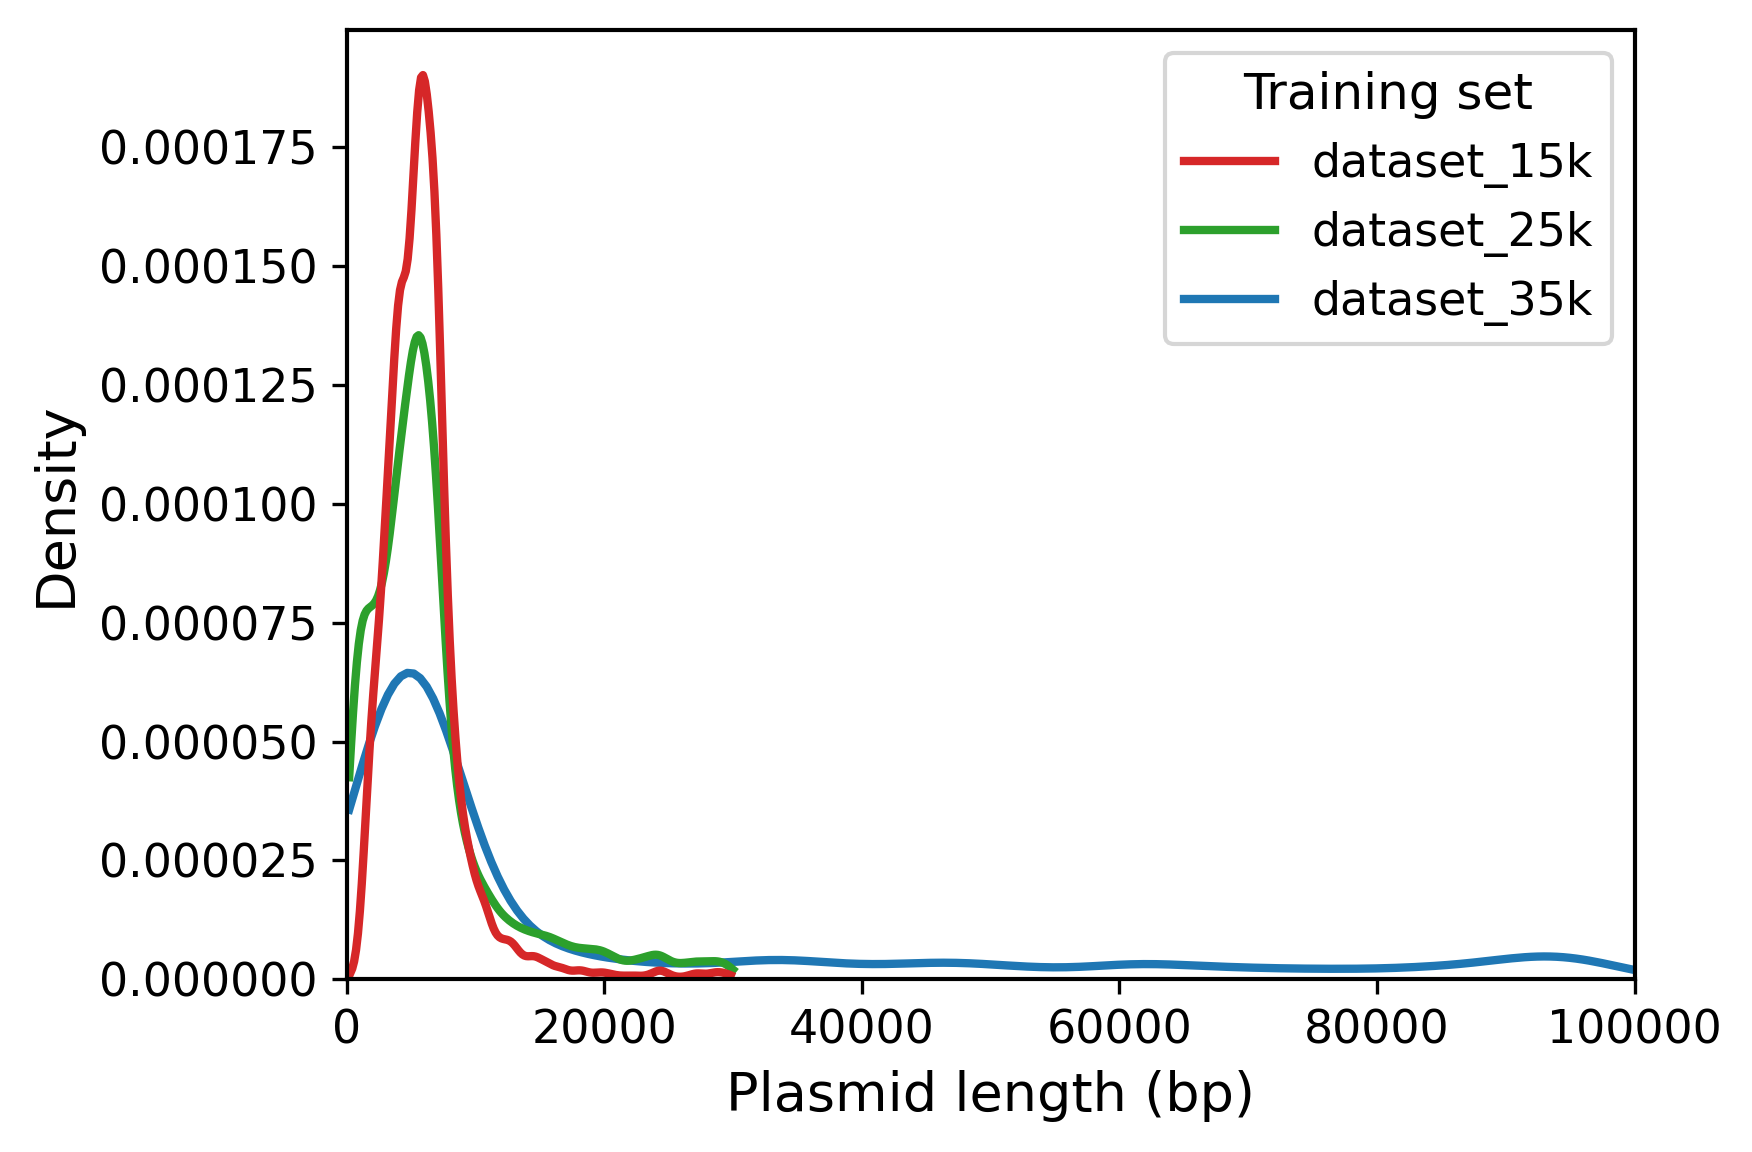

In [2]:
# Locked colour mapping (15k=red, 25k=green, 35k=blue)
palette = {
    "dataset_15k": "#d62728",  # red
    "dataset_25k": "#2ca02c",  # green
    "dataset_35k": "#1f77b4",  # blue
}
order = ["dataset_15k", "dataset_25k", "dataset_35k"]

# ─── Plot density distributions ───────────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(6,4))
sns.kdeplot(
    data=df_all,
    x="length_bp",
    hue="dataset",
    hue_order=order,          # ensure consistent ordering
    palette=palette,          # fixed mapping
    common_norm=False,
    linewidth=2,
    clip=(0, 100000),         # constrain KDE eval domain
    cut=0,                    # don't extend beyond data
    ax=ax
)

# Axis + legend
ax.set_xlabel("Plasmid length (bp)")
ax.set_ylabel("Density")
ax.set_xlim(0, 100000)

# Explicit legend keyed to our palette & order (avoids seaborn auto-mismatch)
handles = [Line2D([0], [0], color=palette[name], lw=2) for name in order]
ax.legend(handles, order, title="Training set", loc="upper right", frameon=True)

fig.tight_layout()
plt.show()


In [3]:
# save vector pdf
OUT = Path("figures"); OUT.mkdir(exist_ok=True, parents=True)
fig.savefig(OUT/"length_density.pdf", bbox_inches="tight")
plt.close(fig)

/tmp/ipykernel_238054/1006049438.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_238054/1006049438.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["dataset_15k", "dataset_25k", "dataset_35k"])


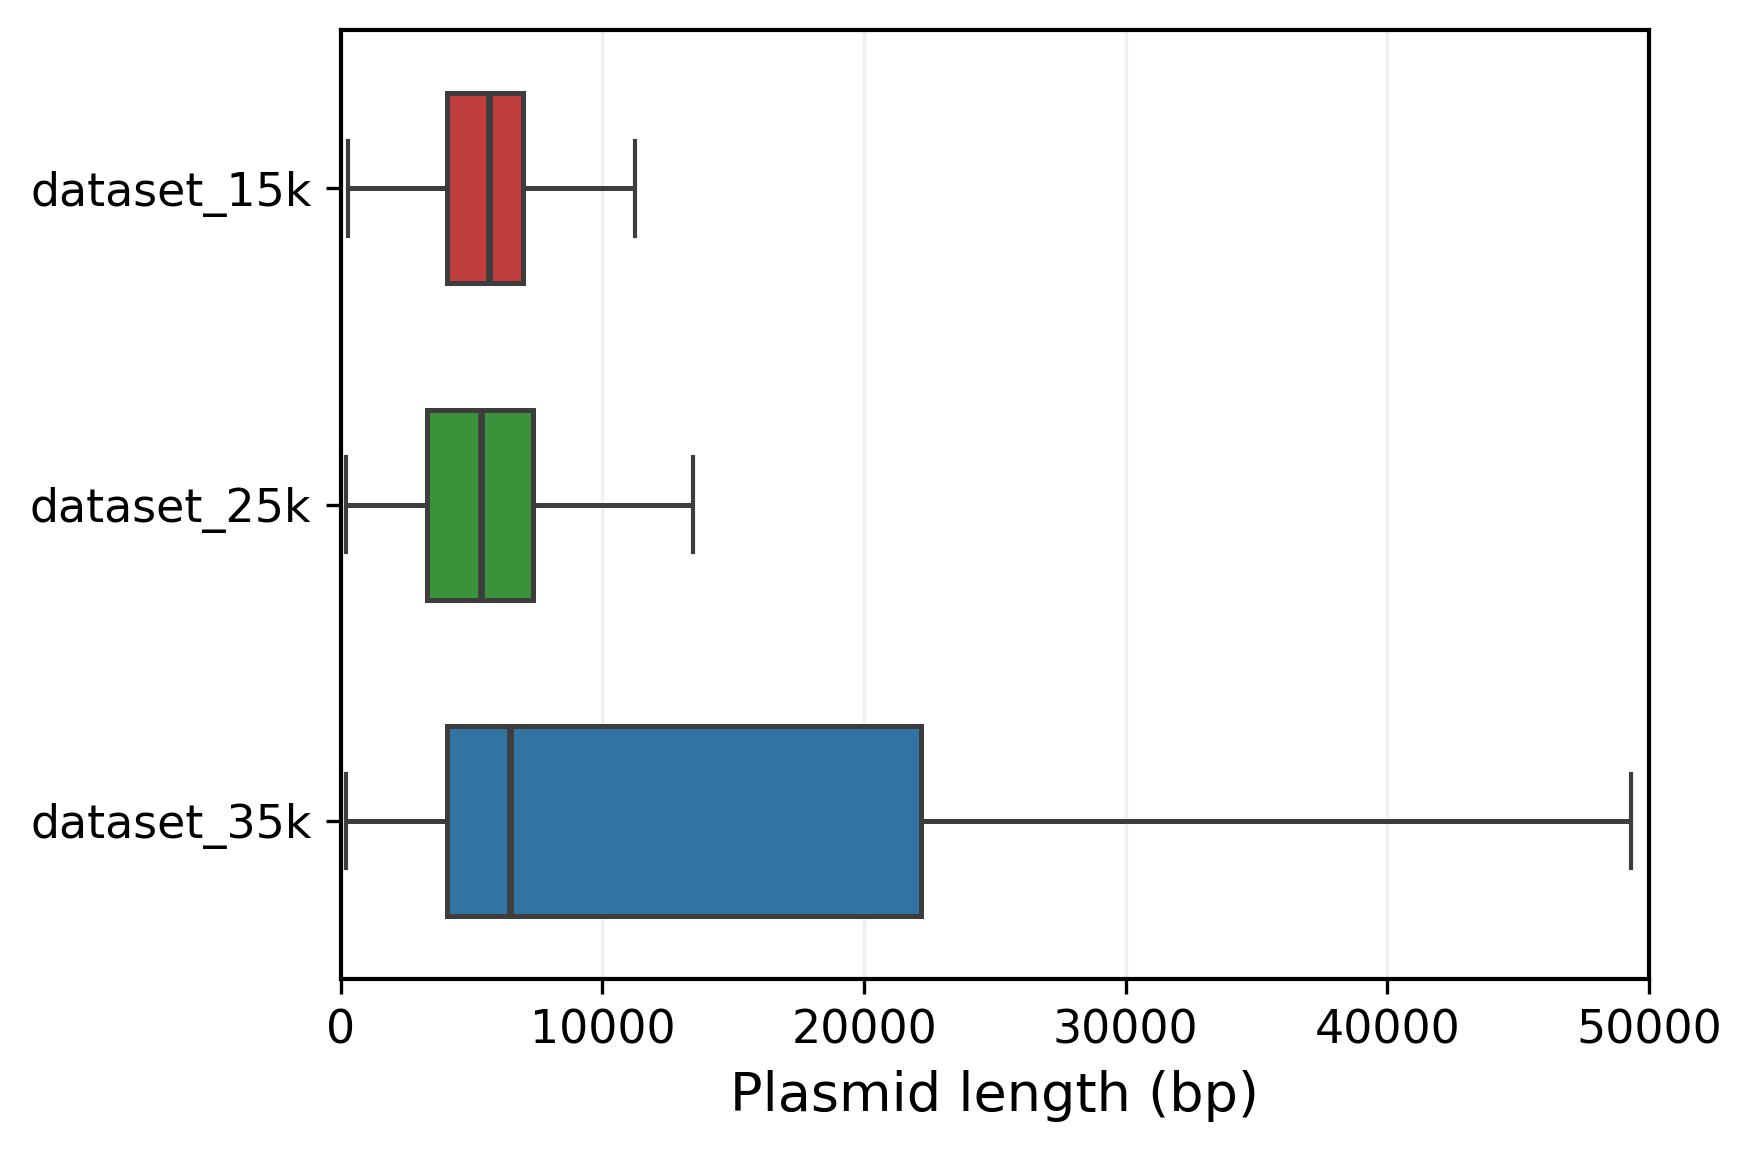

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Consistent order & palette (15k=red, 25k=green, 35k=blue)
order = ["dataset_15k", "dataset_25k", "dataset_35k"]
palette = {
    "dataset_15k": "#d62728",
    "dataset_25k": "#2ca02c",
    "dataset_35k": "#1f77b4",
}

# LaTeX-friendly style
plt.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.size": 12, "axes.labelsize": 13,
    "axes.titlesize": 13, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "figure.dpi": 300
})

fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(
    data=df_all,
    y="dataset", x="length_bp",
    order=order,
    palette=palette,
    width=0.6,
    showcaps=True,
    showfliers=False,     # keep clean; toggle True if you want outliers
    whiskerprops=dict(linewidth=1.2),
    boxprops=dict(linewidth=1.2),
    medianprops=dict(linewidth=1.6),
    ax=ax
)

ax.set_xlabel("Plasmid length (bp)")
ax.set_ylabel("")
ax.set_xlim(0, 50000)
ax.set_yticklabels(["dataset_15k", "dataset_25k", "dataset_35k"])
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()

# Preview
plt.show()

# Optional save
# OUT = Path("figures"); OUT.mkdir(exist_ok=True, parents=True)
# fig.savefig(OUT/"length_boxplots.pdf", bbox_inches="tight")
# plt.close(fig)


In [5]:
# print median lengths per dataset
medians = df_all.groupby("dataset")["length_bp"].median()
for dataset, median in medians.items():
    print(f"{dataset}: {median} bp")
    


dataset_15k: 5681.0 bp
dataset_25k: 5364.0 bp
dataset_35k: 6488.0 bp


In [4]:
# Optional save
OUT = Path("figures"); OUT.mkdir(exist_ok=True, parents=True)
fig.savefig(OUT/"length_boxplots.pdf", bbox_inches="tight")
plt.close(fig)

### GC

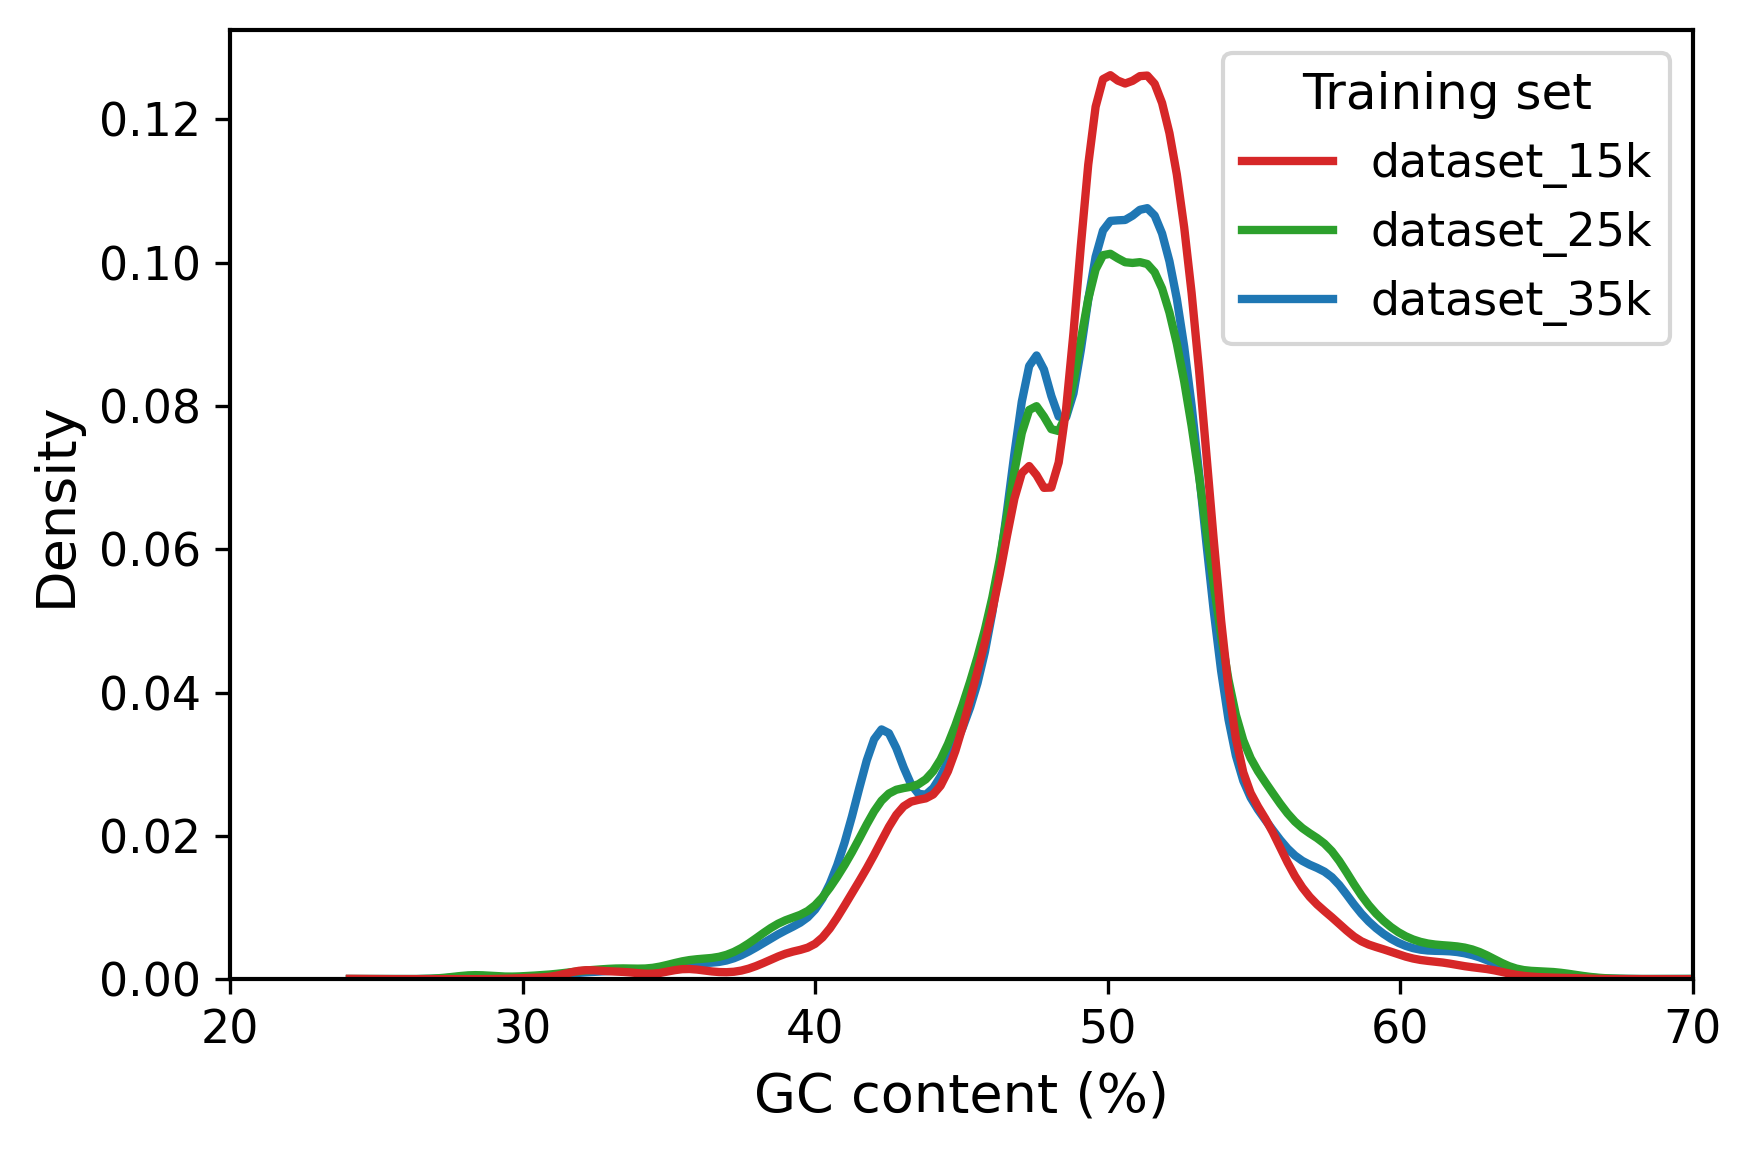

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from pathlib import Path
import numpy as np

# ─── File paths ───────────────────────────────────────────────
ADDGENE = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/metadata/ft_metadata/addgene_plasmid_metadata.csv"
FT25    = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/metadata/ft_metadata/ecoli_pbd_ft25.tsv"
FT15    = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/metadata/ft_metadata/ecoli_pdb_ft15.tsv"
FT35    = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/metadata/ft_metadata/Ecoli_pdb_ft35.tsv"

def _read(path):
    return pd.read_csv(path) if path.endswith(".csv") else pd.read_csv(path, sep="\t")

def _find_gc_col(df):
    # look for any column mentioning 'gc' (case-insensitive)
    candidates = [c for c in df.columns if "gc" in c.lower()]
    return candidates[0] if candidates else None

def _to_gc_percent(series):
    s = pd.to_numeric(series, errors="coerce")
    if s.max() is None or np.isnan(s.max()):
        return s  # will be NaN, handled later
    if s.max() <= 1.0:       # fraction
        return s * 100.0
    # already in percent (or per-cent like 35–70)
    return s

def load_with_addgene(main_file, addgene_file, name):
    main = _read(main_file)
    addg = _read(addgene_file)

    # unify length
    if "Size (bp)" not in main.columns:
        raise KeyError(f"'Size (bp)' not found in {main_file}. Found: {list(main.columns)}")
    if "Size (bp)" not in addg.columns:
        raise KeyError(f"'Size (bp)' not found in {addgene_file}. Found: {list(addg.columns)}")

    main["length_bp"] = pd.to_numeric(main["Size (bp)"], errors="coerce")
    addg["length_bp"] = pd.to_numeric(addg["Size (bp)"], errors="coerce")

    # detect & convert GC → percent
    gc_col_main = _find_gc_col(main)
    gc_col_addg = _find_gc_col(addg)

    if gc_col_main is None:
        print(f"[warn] No GC column detected in {main_file}. Columns: {list(main.columns)}")
        main["gc_percent"] = np.nan
    else:
        main["gc_percent"] = _to_gc_percent(main[gc_col_main])

    if gc_col_addg is None:
        print(f"[warn] No GC column detected in {addgene_file}. Columns: {list(addg.columns)}")
        addg["gc_percent"] = np.nan
    else:
        addg["gc_percent"] = _to_gc_percent(addg[gc_col_addg])

    df = pd.concat([main[["length_bp","gc_percent"]], addg[["length_bp","gc_percent"]]], ignore_index=True)
    df["dataset"] = name
    return df

df25 = load_with_addgene(FT25, ADDGENE, "dataset_25k")
df15 = load_with_addgene(FT15, ADDGENE, "dataset_15k")
df35 = load_with_addgene(FT35, ADDGENE, "dataset_35k")

df_all = pd.concat([df15, df25, df35], ignore_index=True)
df_all = df_all.dropna(subset=["gc_percent"])           # keep rows with GC available
df_all = df_all[(df_all["gc_percent"] >= 0) & (df_all["gc_percent"] <= 100)]

# ─── Plot GC% density ────────────────────────────────────────
order = ["dataset_15k", "dataset_25k", "dataset_35k"]
palette = {
    "dataset_15k": "#d62728",  # red
    "dataset_25k": "#2ca02c",  # green
    "dataset_35k": "#1f77b4",  # blue
}

plt.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.size": 12, "axes.labelsize": 13, "axes.titlesize": 13,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "figure.dpi": 300
})

fig, ax = plt.subplots(figsize=(6,4))
sns.kdeplot(
    data=df_all,
    x="gc_percent",
    hue="dataset",
    hue_order=order,
    palette=palette,
    common_norm=False,
    linewidth=2,
    clip=(0, 100),
    cut=0,
    ax=ax
)
ax.set_xlabel("GC content (%)")
ax.set_ylabel("Density")
ax.set_xlim(20, 70)

handles = [Line2D([0], [0], color=palette[n], lw=2) for n in order]
ax.legend(handles, order, title="Training set", loc="upper right", frameon=True)

fig.tight_layout()
plt.show()


In [2]:
# save vector pdf
OUT = Path("figures"); OUT.mkdir(exist_ok=True, parents=True)
fig.savefig(OUT/"gc_density.pdf", bbox_inches="tight")
plt.close(fig)

| Dataset              | GenBank | RefSeq | PLSDB | IMGPR | DDBJ | COMPASS | ENA | Kraken2 | TPA | Addgene | Other | **Total** |
| -------------------- | ------- | ------ | ----- | ----- | ---- | ------- | --- | ------- | --- | ------- | ----- | --------- |
| **PlasmidGPT-ft35k** | 14878   | 1892   | 624   | 5047  | 1245 | 1160    | 0   | 0       | 0   | 10304   | 0     | **35150** |
| **PlasmidGPT-ft25k** | 10464   | 1240   | 239   | 3906  | 736  | 344     | 0   | 0       | 0   | 10304   | 0     | **27233** |
| **PlasmidGPT-ft15k** | 3022    | 245    | 211   | 1     | 368  | 334     | 0   | 0       | 0   | 10304   | 0     | **14485** |


### Topology

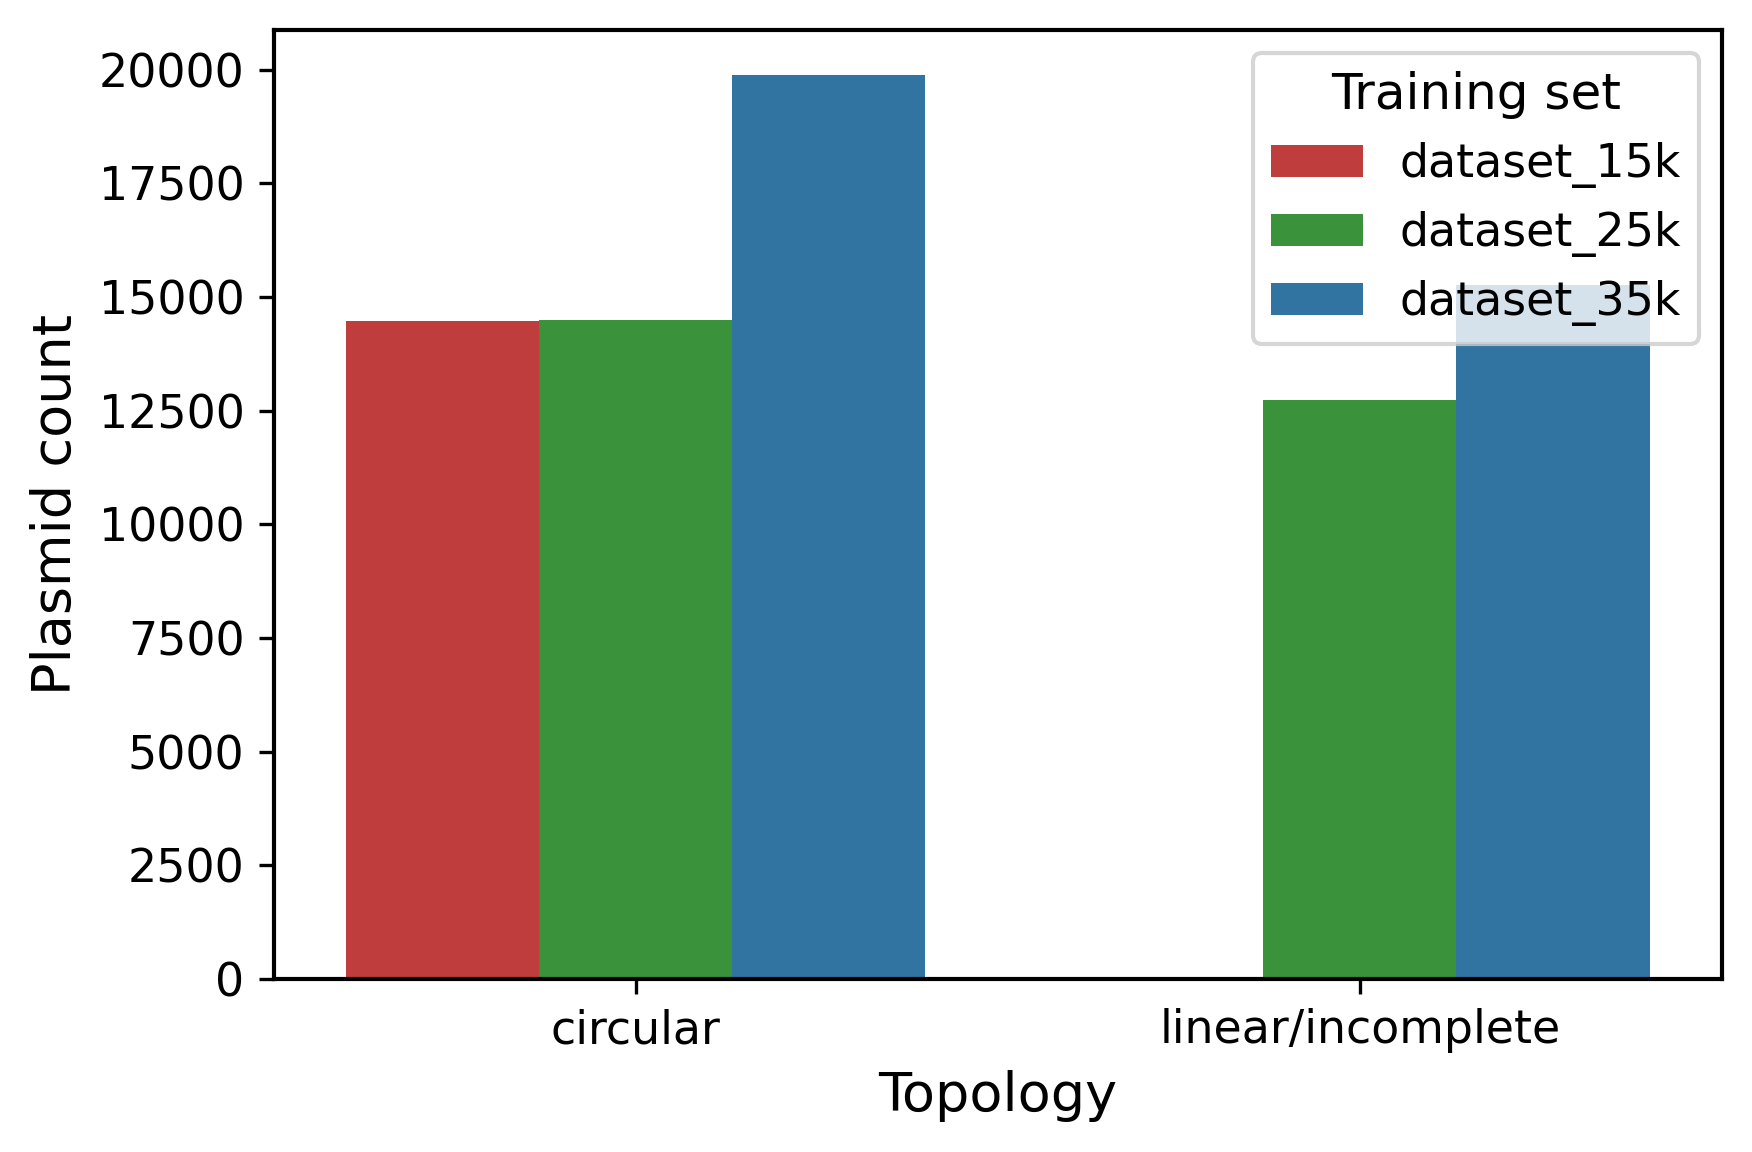

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ─── File paths ───────────────────────────────────────────────
ADDGENE = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/metadata/ft_metadata/addgene_plasmid_metadata.csv"
FT25    = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/metadata/ft_metadata/ecoli_pbd_ft25.tsv"
FT15    = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/metadata/ft_metadata/ecoli_pdb_ft15.tsv"
FT35    = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/metadata/ft_metadata/Ecoli_pdb_ft35.tsv"

def load_counts(main_file, addgene_file, dataset_name):
    main = pd.read_csv(main_file, sep="\t") if main_file.endswith(".tsv") else pd.read_csv(main_file)
    addg = pd.read_csv(addgene_file)

    # Normalize topology: everything not 'circular' → 'linear/incomplete'
    if "Topology" in main.columns:
        topo = main["Topology"].astype(str).str.lower()
        topo = topo.apply(lambda x: "circular" if x == "circular" else "linear/incomplete")
        main_counts = topo.value_counts()
    else:
        main_counts = pd.Series(dtype=int)

    # Addgene assumed circular
    addg_counts = pd.Series({"circular": len(addg)})

    # Combine and ensure both categories exist
    combined = main_counts.add(addg_counts, fill_value=0).astype(int)
    for cat in ["circular", "linear/incomplete"]:
        if cat not in combined:
            combined[cat] = 0

    out = combined.reset_index()
    out.columns = ["topology", "count"]
    out["dataset"] = dataset_name
    return out

df15 = load_counts(FT15, ADDGENE, "dataset_15k")
df25 = load_counts(FT25, ADDGENE, "dataset_25k")
df35 = load_counts(FT35, ADDGENE, "dataset_35k")

df_top = pd.concat([df15, df25, df35], ignore_index=True)

# ─── Plot: x = topology; hue = dataset (3 bars per category) ─
order_x = ["circular", "linear/incomplete"]
hue_order = ["dataset_15k", "dataset_25k", "dataset_35k"]
palette = {
    "dataset_15k": "#d62728",  # red
    "dataset_25k": "#2ca02c",  # green
    "dataset_35k": "#1f77b4",  # blue
}

plt.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.size": 12, "axes.labelsize": 13, "axes.titlesize": 13,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "figure.dpi": 300
})

fig, ax = plt.subplots(figsize=(6,4))

sns.barplot(
    data=df_top,
    x="topology", y="count",
    hue="dataset",
    order=order_x,
    hue_order=hue_order,
    palette=palette,
    ax=ax
)

ax.set_xlabel("Topology")
ax.set_ylabel("Plasmid count")
ax.legend(title="Training set", loc="upper right", frameon=True)
fig.tight_layout()
plt.show()


In [35]:
from pathlib import Path
OUT = Path("figures"); OUT.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT/"topology_grouped_bars.pdf", bbox_inches="tight")
plt.close(fig)